#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Import Datasets

In [2]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test
%store -r Set1_X_Train_scaled_2
%store -r Set1_X_Test_scaled_2

#### Support Vector Machine

In [3]:
'''
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

svr = SVR()

grid_search = GridSearchCV(svr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(Set1_X_Train_scaled, Set1_y_Train)

best_kernel = grid_search.best_params_['kernel']
best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']
best_score = -grid_search.best_score_  

print("Best Kernel:", best_kernel)
print("Best C:", best_C)
print("Best gamma:", best_gamma)
print("Best Score (MSE):", best_score)

mean_test_scores = grid_search.cv_results_['mean_test_score']
params = grid_search.cv_results_['params']

for param, score in zip(params, mean_test_scores):
    print(f"Kernel: {param['kernel']}, C: {param['C']}, Gamma: {param['gamma']}, Mean Test MSE: {-score}")
'''

'\nparam_grid = {\n    \'kernel\': [\'linear\', \'poly\', \'rbf\', \'sigmoid\'],\n    \'C\': [0.001, 0.01, 0.1, 1, 10, 100],\n    \'gamma\': [0.001, 0.01, 0.1, 1, 10]\n}\n\nsvr = SVR()\n\ngrid_search = GridSearchCV(svr, param_grid=param_grid, cv=5, scoring=\'neg_mean_squared_error\', verbose=1)\ngrid_search.fit(Set1_X_Train_scaled, Set1_y_Train)\n\nbest_kernel = grid_search.best_params_[\'kernel\']\nbest_C = grid_search.best_params_[\'C\']\nbest_gamma = grid_search.best_params_[\'gamma\']\nbest_score = -grid_search.best_score_  \n\nprint("Best Kernel:", best_kernel)\nprint("Best C:", best_C)\nprint("Best gamma:", best_gamma)\nprint("Best Score (MSE):", best_score)\n\nmean_test_scores = grid_search.cv_results_[\'mean_test_score\']\nparams = grid_search.cv_results_[\'params\']\n\nfor param, score in zip(params, mean_test_scores):\n    print(f"Kernel: {param[\'kernel\']}, C: {param[\'C\']}, Gamma: {param[\'gamma\']}, Mean Test MSE: {-score}")\n'

In [4]:
svm_reg = SVR(kernel='sigmoid', C=10, gamma=0.01)

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

svm_reg.fit(Set1_X_Train_scaled, Set1_y_Train_array)

svm_reg_pred_train = svm_reg.predict(Set1_X_Train_scaled)
svm_reg_pred_test = svm_reg.predict(Set1_X_Test_scaled)

svm_reg_pred_test_int = svm_reg_pred_test.astype(int)
svm_reg_pred_train_int = svm_reg_pred_train.astype(int)

#### Support Vector Machine Evaluation 

In [5]:
# Mean Squared Error
mse_train_svm = mean_squared_error(Set1_y_Train_array, svm_reg_pred_train_int)
mse_test_svm = mean_squared_error(Set1_y_Test_array, svm_reg_pred_test_int)

# Root Mean Squared Error
rmse_train_svm = np.sqrt(mse_train_svm)
rmse_test_svm = np.sqrt(mse_test_svm)

# Mean Absolute Error
mae_train_svm = mean_absolute_error(Set1_y_Train_array, svm_reg_pred_train_int)
mae_test_svm = mean_absolute_error(Set1_y_Test_array, svm_reg_pred_test_int)

# R2 Score
r2_train_svm = r2_score(Set1_y_Train_array, svm_reg_pred_train_int)
r2_test_svm = r2_score(Set1_y_Test_array, svm_reg_pred_test_int)

# Coefficient of Determination
cod_train_svm = explained_variance_score(Set1_y_Train_array, svm_reg_pred_train_int)
cod_test_svm = explained_variance_score(Set1_y_Test_array, svm_reg_pred_test_int)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_svm)
print("Root Mean Squared Error:", rmse_train_svm)
print("Mean Absolute Error:", mae_train_svm)
print("R-squared Score:", r2_train_svm)
print("Coefficient of Determination:", cod_train_svm)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_svm)
print("Root Mean Squared Error:", rmse_test_svm)
print("Mean Absolute Error:", mae_test_svm)
print("R-squared Score:", r2_test_svm)
print("Coefficient of Determination:", cod_test_svm)

--Training Set Evaluation--
Mean Squared Error: 2210.306432068247
Root Mean Squared Error: 47.0138961592022
Mean Absolute Error: 34.04139401870971
R-squared Score: 0.5341192397801319
Coefficient of Determination: 0.5556261072606461

--Testing Set Evaluation--
Mean Squared Error: 1173.37
Root Mean Squared Error: 34.2544887569498
Mean Absolute Error: 27.81
R-squared Score: 0.3205219432897538
Coefficient of Determination: 0.3210445652642213


#### Plot Evaluation Results

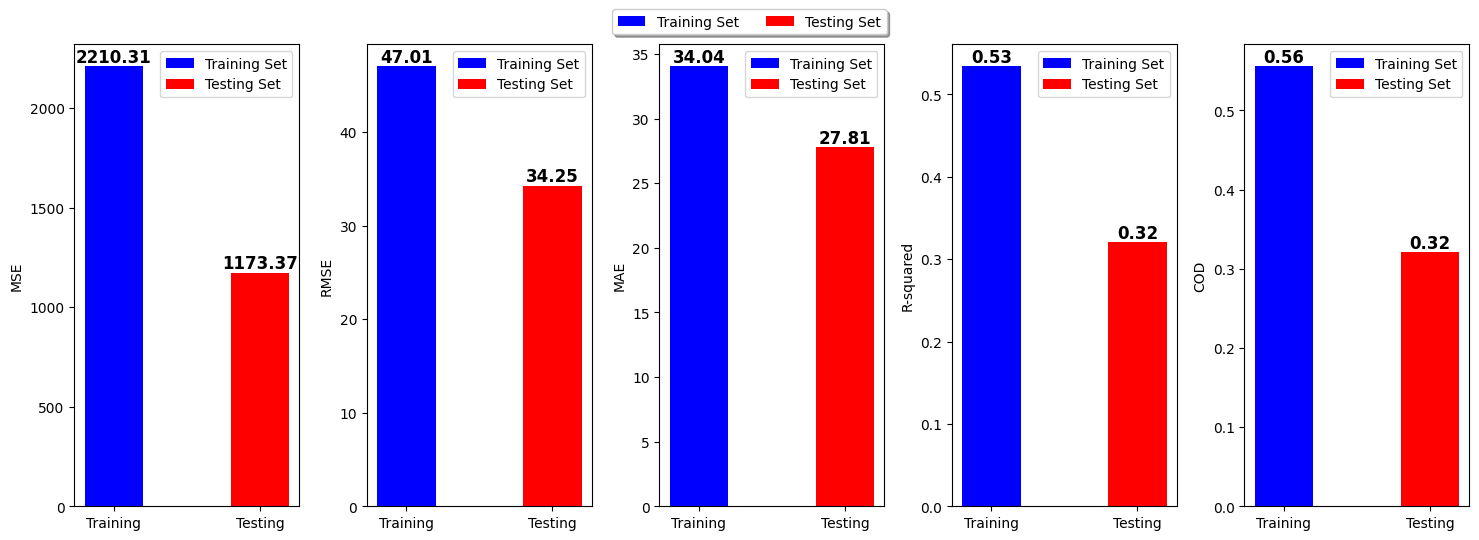

In [6]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_svm, rmse_train_svm, mae_train_svm, r2_train_svm, cod_train_svm]
test_metrics = [mse_test_svm, rmse_test_svm, mae_test_svm, r2_test_svm, cod_test_svm]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Actual vs Predicted Values

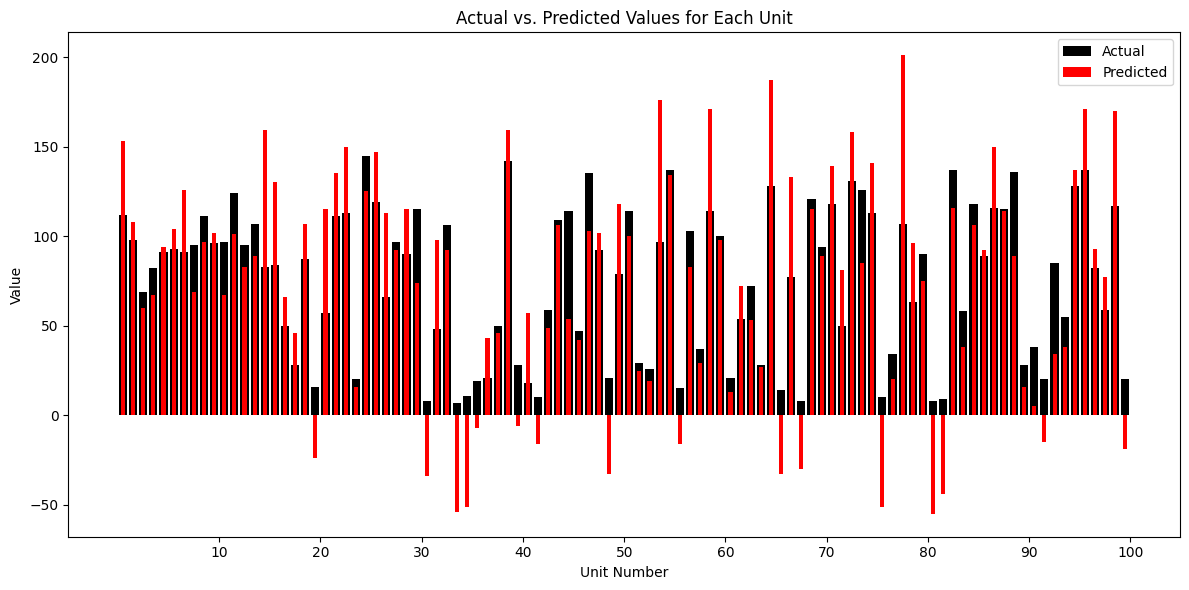

In [7]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(svm_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### Support Vector Machine (Dropped Constant Columns)

In [8]:
svm_reg_2 = SVR(kernel='sigmoid', C=10, gamma=0.01)

Set1_y_Train_array_2 = Set1_y_Train.values.ravel()
Set1_y_Test_array_2 = Set1_y_Test.values.ravel()

svm_reg_2.fit(Set1_X_Train_scaled_2, Set1_y_Train_array_2)

svm_reg_pred_train_2 = svm_reg_2.predict(Set1_X_Train_scaled_2)
svm_reg_pred_test_2 = svm_reg_2.predict(Set1_X_Test_scaled_2)

svm_reg_pred_test_int_2 = svm_reg_pred_test_2.astype(int)
svm_reg_pred_train_int_2 = svm_reg_pred_train_2.astype(int)

#### Support Vector Machine Evaluation

In [9]:
# Mean Squared Error
mse_train_svm_2 = mean_squared_error(Set1_y_Train_array_2, svm_reg_pred_train_int_2)
mse_test_svm_2 = mean_squared_error(Set1_y_Test_array_2, svm_reg_pred_test_int_2)

# Root Mean Squared Error
rmse_train_svm_2 = np.sqrt(mse_train_svm_2)
rmse_test_svm_2 = np.sqrt(mse_test_svm_2)

# Mean Absolute Error
mae_train_svm_2 = mean_absolute_error(Set1_y_Train_array_2, svm_reg_pred_train_int_2)
mae_test_svm_2 = mean_absolute_error(Set1_y_Test_array_2, svm_reg_pred_test_int_2)

# R2 Score
r2_train_svm_2 = r2_score(Set1_y_Train_array_2, svm_reg_pred_train_int_2)
r2_test_svm_2 = r2_score(Set1_y_Test_array_2, svm_reg_pred_test_int_2)

# Coefficient of Determination
cod_train_svm_2 = explained_variance_score(Set1_y_Train_array_2, svm_reg_pred_train_int_2)
cod_test_svm_2 = explained_variance_score(Set1_y_Test_array_2, svm_reg_pred_test_int_2)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_svm_2)
print("Root Mean Squared Error:", rmse_train_svm_2)
print("Mean Absolute Error:", mae_train_svm_2)
print("R-squared Score:", r2_train_svm_2)
print("Coefficient of Determination:", cod_train_svm_2)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_svm_2)
print("Root Mean Squared Error:", rmse_test_svm_2)
print("Mean Absolute Error:", mae_test_svm_2)
print("R-squared Score:", r2_test_svm_2)
print("Coefficient of Determination:", cod_test_svm_2)

--Training Set Evaluation--
Mean Squared Error: 2210.808152779797
Root Mean Squared Error: 47.019231733194
Mean Absolute Error: 34.0638359749891
R-squared Score: 0.5340134888203898
Coefficient of Determination: 0.5554286064165972

--Testing Set Evaluation--
Mean Squared Error: 1173.76
Root Mean Squared Error: 34.26018096858217
Mean Absolute Error: 27.8
R-squared Score: 0.32029610110688134
Coefficient of Determination: 0.3206484149121622


#### Plot Evaluation Results

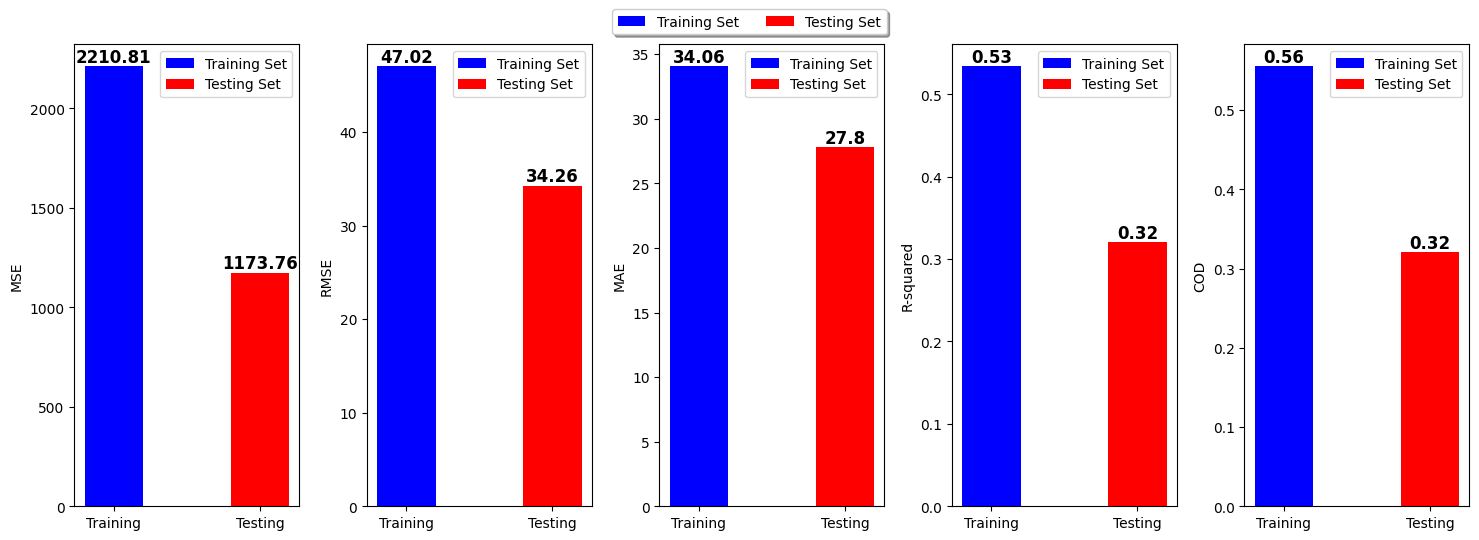

In [13]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics_2 = [mse_train_svm_2, rmse_train_svm_2, mae_train_svm_2, r2_train_svm_2, cod_train_svm_2]
test_metrics_2 = [mse_test_svm_2, rmse_test_svm_2, mae_test_svm_2, r2_test_svm_2, cod_test_svm_2]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics_2, test_metrics_2)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Predicted vs Actual Values

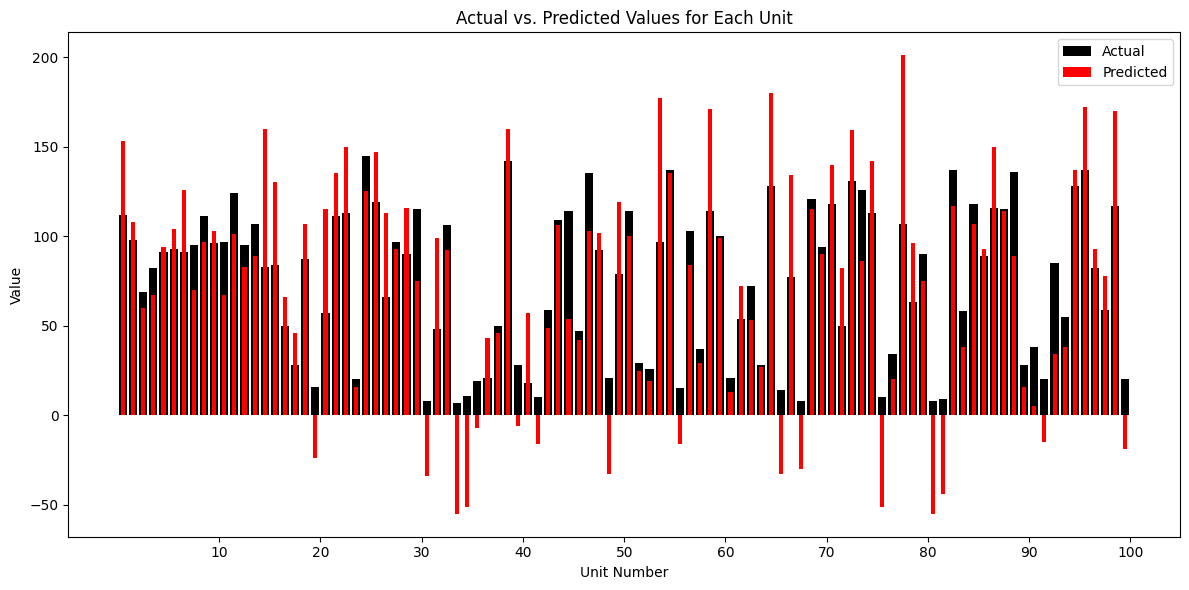

In [12]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(svm_reg_pred_test_int_2)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()